<a href="https://colab.research.google.com/github/haru452/anime_super-resolution/blob/main/hexgon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

読み込んだ画像:
  Frame 0: shape=(128, 127)
  Frame 1: shape=(128, 127)
  Frame 2: shape=(128, 126)
  Frame 3: shape=(126, 125)

回転補正を適用中...

回転補正をground truthにも適用中...
クロップ後のサイズ: (98, 97)
クロップ後のoriginalのサイズ: (196, 195)

サブピクセル位置合わせを実行中...
  Frame 0: dx = +0.0000, dy = +0.0000 (基準)
  Frame 1: dx = +0.0372, dy = -0.1689 (信頼度: 0.9034)
  Frame 2: dx = -0.2616, dy = -0.2464 (信頼度: 0.8980)
  Frame 3: dx = -0.3689, dy = -0.3459 (信頼度: 0.8388)

散布点の総数: 38024 点 (9506 画素 x 4 枚)
生成した六角格子点数: 175764 点 (spacing=0.25)

六角格子への補間処理を実行中...

六角格子をラスタ画像化中 (k=4 重み付き平均)...


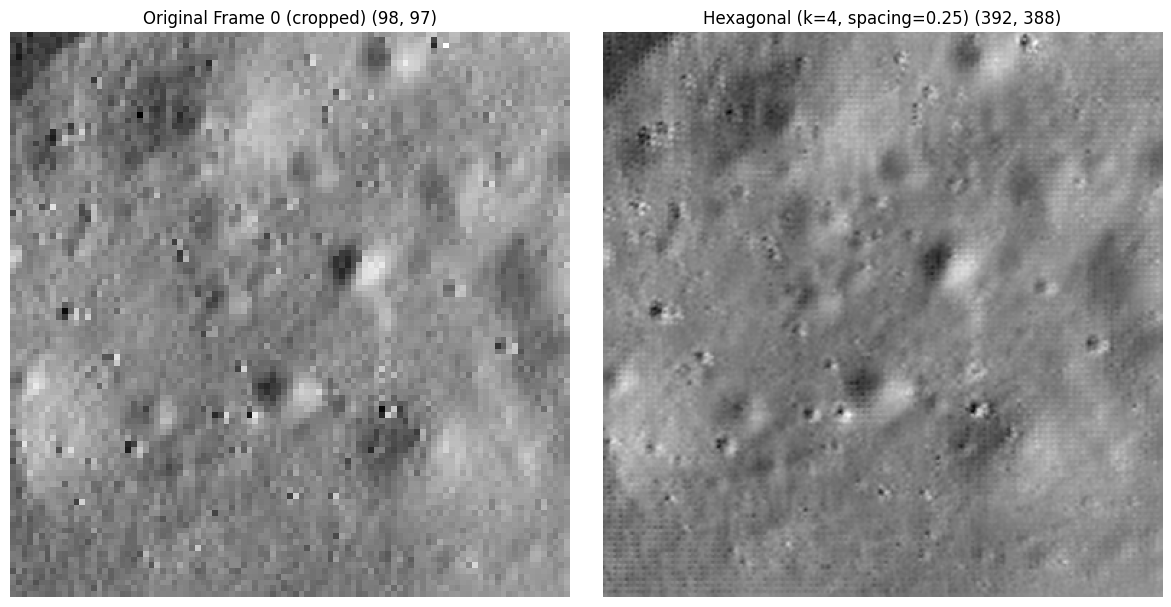

結果を 'hex_reconstruction_k4.png' に保存しました。


In [26]:
import glob
import math
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.spatial import cKDTree

# ======================================================
# 0. 画像の読み込み
# ======================================================
paths = sorted(glob.glob("aligned_img*.tiff"))  # bs1.png ~ bs4.png
#paths = sorted(glob.glob("bs*.png"))  # bs1.png ~ bs4.png
images_original = [cv2.imread(p, cv2.IMREAD_GRAYSCALE).astype(np.float32) for p in paths]
images = []
for img in images_original:
  new_size = (img.shape[1] // 2, img.shape[0] // 2)
  images.append(cv2.resize(img, new_size, interpolation=cv2.INTER_CUBIC))

if not images or any(img is None for img in images):
    raise FileNotFoundError("画像が見つかりません。paths のパスを確認してください。")

print("読み込んだ画像:")
for i, img in enumerate(images):
    print(f"  Frame {i}: shape={img.shape}")


# ======================================================
# 1. 回転補正(Frame 0 の向きに全フレームを合わせる)
# ======================================================
def align_rotation(base, img):
    orb = cv2.ORB_create(1000)
    kp1, des1 = orb.detectAndCompute(base.astype(np.uint8), None)
    kp2, des2 = orb.detectAndCompute(img.astype(np.uint8), None)
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = sorted(bf.match(des1, des2), key=lambda m: m.distance)[:50]
    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])
    M, _ = cv2.estimateAffinePartial2D(pts2, pts1)
    h, w = base.shape
    aligned = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LANCZOS4,
                              borderMode=cv2.BORDER_REPLICATE)
    return aligned


print("\n回転補正を適用中...")
aligned_images = [images[0]] + [align_rotation(images[0], img) for img in images[1:]]
for img in aligned_images:
  cv2.imwrite(f"bs{aligned_images}.png",img)

print("\n回転補正をground truthにも適用中...")
aligned_images_original = [images_original[0]] + [align_rotation(images_original[0], img) for img in images_original[1:]]


# ======================================================
# 2. 有効領域のクロップ(縁のアーティファクトを除去)
# ======================================================
def crop_valid_region(imgs, margin_ratio=0.12):
    h, w = imgs[0].shape
    my, mx = int(h * margin_ratio), int(w * margin_ratio)
    return [img[my:h - my, mx:w - mx] for img in imgs]


aligned_images = crop_valid_region(aligned_images, margin_ratio=0.12)
h, w = aligned_images[0].shape
print(f"クロップ後のサイズ: {aligned_images[0].shape}")

aligned_images_original = crop_valid_region(aligned_images_original, margin_ratio=0.12)
h1, w1 = aligned_images_original[0].shape
print(f"クロップ後のoriginalのサイズ: {aligned_images_original[0].shape}")


# ======================================================
# 3. サブピクセルオフセット推定
# ======================================================
def estimate_offsets(frames):
    offsets = []
    base_frame = frames[0].astype(np.float32)

    hh, ww = base_frame.shape
    cy, cx = hh // 2, ww // 2
    dy_roi, dx_roi = int(hh * 0.3), int(ww * 0.3)

    base_roi = base_frame[cy-dy_roi : cy+dy_roi, cx-dx_roi : cx+dx_roi]
    win = cv2.createHanningWindow((base_roi.shape[1], base_roi.shape[0]), cv2.CV_32F)

    print("\nサブピクセル位置合わせを実行中...")
    for i, frame in enumerate(frames):
        if i == 0:
            offsets.append((0.0, 0.0))
            print(f"  Frame {i}: dx = +0.0000, dy = +0.0000 (基準)")
            continue

        frame_roi = frame.astype(np.float32)[cy-dy_roi : cy+dy_roi, cx-dx_roi : cx+dx_roi]

        try:
            shift, response = cv2.phaseCorrelate(base_roi, frame_roi, win)
            dx, dy = shift
            offsets.append((dx, dy))
            print(f"  Frame {i}: dx = {dx:+.4f}, dy = {dy:+.4f} (信頼度: {response:.4f})")
        except Exception as e:
            print(f"  Frame {i}: 位置合わせ失敗。エラー: {e}")
            offsets.append((0.0, 0.0))

    return offsets

estimated_offsets = estimate_offsets(aligned_images)


# ======================================================
# 4. 全フレームの画素を「散布点群」として基準座標系にまとめる
# ======================================================
def build_point_cloud(images, offsets):
    base_mean = np.mean(images[0])
    hh, ww = images[0].shape
    jj, ii = np.meshgrid(np.arange(ww), np.arange(hh))

    xs, ys, vs = [], [], []
    for img, (dx, dy) in zip(images, offsets):
        norm = img * (base_mean / (np.mean(img) + 1e-8))
        xs.append((jj - dx).ravel())
        ys.append((ii - dy).ravel())
        vs.append(norm.ravel())

    return np.concatenate(xs), np.concatenate(ys), np.concatenate(vs)


pts_x, pts_y, vals = build_point_cloud(aligned_images, estimated_offsets)
print(f"\n散布点の総数: {len(vals)} 点"
      f" ({aligned_images[0].size} 画素 x {len(aligned_images)} 枚)")


# ======================================================
# 5. 六角格子(ハニカム格子)の生成
# ======================================================
def generate_hex_grid(h, w, spacing):
    row_spacing = spacing * math.sqrt(3) / 2.0
    points = []
    row = 0
    y = 0.0
    while y < h:
        x_offset = (spacing / 2.0) if (row % 2 == 1) else 0.0
        x = x_offset
        while x < w:
            points.append((x, y))
            x += spacing
        y += row_spacing
        row += 1
    return np.array(points)


# 4倍超解像度 (画素の間隔を 0.25 に設定)
HEX_SPACING = 0.25
hex_points = generate_hex_grid(h, w, HEX_SPACING)
print(f"生成した六角格子点数: {len(hex_points)} 点 (spacing={HEX_SPACING})")


# ======================================================
# 6. 散布データを六角格子点へ補間 (cubic)
# ======================================================
print("\n六角格子への補間処理を実行中...")
hex_values = griddata((pts_x, pts_y), vals, hex_points, method='cubic')

nan_mask = np.isnan(hex_values)
if nan_mask.any():
    hex_values_nn = griddata((pts_x, pts_y), vals, hex_points, method='nearest')
    hex_values[nan_mask] = hex_values_nn[nan_mask]


# ======================================================
# 7. 六角格子をラスタ画像として描画 (k=4 距離加重平均)
# ======================================================
def rasterize_hex_k4(hex_points, hex_values, h, w, upscale=4, k=4):
    out_h, out_w = h * upscale, w * upscale
    yy, xx = np.meshgrid(np.arange(out_h) / upscale, np.arange(out_w) / upscale, indexing='ij')
    query_pts = np.stack([xx.ravel(), yy.ravel()], axis=-1)

    # 近傍点の探索 (k=4)
    tree = cKDTree(hex_points)
    distances, idx = tree.query(query_pts, k=k)

    # 距離の逆数による重み付け平均 (Inverse Distance Weighting) を計算
    # 割り算時のゼロ除算を防ぐための小さな定数 eps を設定
    eps = 1e-10
    weights = 1.0 / (distances + eps)
    weights_sum = np.sum(weights, axis=1, keepdims=True)
    normalized_weights = weights / weights_sum

    # 重み付きの値を計算してマッピング
    interpolated_values = np.sum(hex_values[idx] * normalized_weights, axis=1)

    return interpolated_values.reshape(out_h, out_w)


print("\n六角格子をラスタ画像化中 (k=4 重み付き平均)...")
raster_img = rasterize_hex_k4(hex_points, hex_values, h, w, upscale=4, k=4)

raster_norm = cv2.normalize(raster_img, None, 0, 255, cv2.NORM_MINMAX)
raster_u8 = raster_norm.astype(np.uint8)
cv2.imwrite("hex_reconstruction_k4.png", raster_u8)

# ======================================================
# 8. 結果の表示と保存
# ======================================================
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title(f"Original Frame 0 (cropped) {aligned_images[0].shape}")
plt.imshow(aligned_images[0], cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Hexagonal (k=4, spacing=0.25) {raster_u8.shape}")
plt.imshow(raster_u8, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.savefig("hex_comparison_k4.png", dpi=150)
plt.show()


print("結果を 'hex_reconstruction_k4.png' に保存しました。")

生成した四角形格子点数: 152096 点 (spacing=0.25)

四角形格子をラスタ画像化中...
結果を 'square_reconstruction.png' に保存しました。


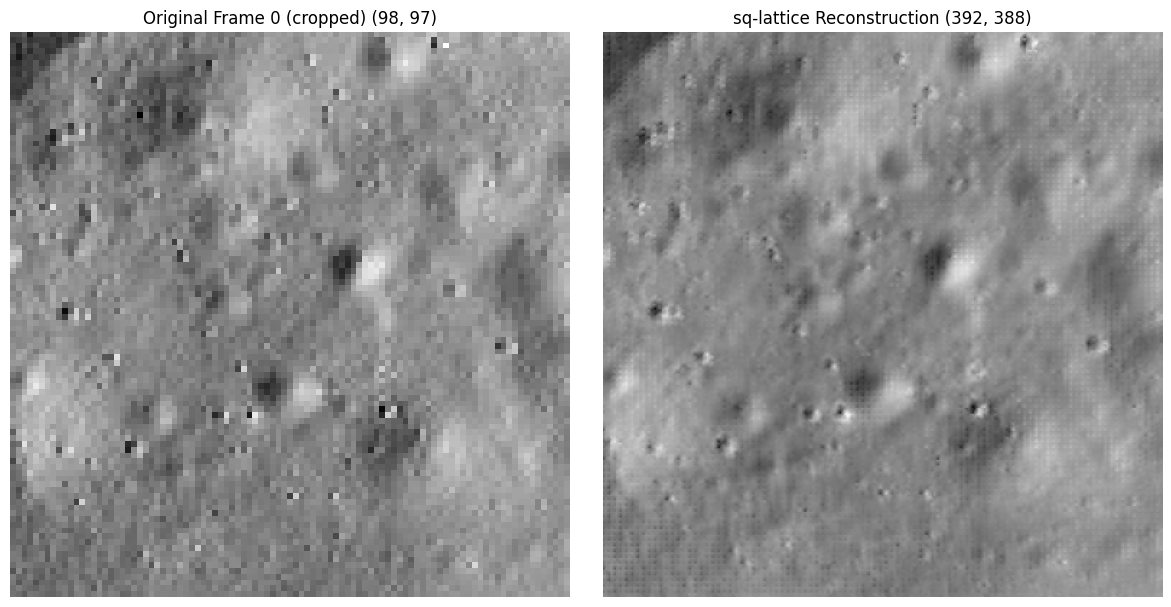

In [28]:
# ======================================================
# 5-2. 四角形格子（正方形格子）の生成
# ======================================================
def generate_square_grid(h, w, spacing):
    """
    spacing: 隣接する格子点どうしの距離。
    六角格子(0.75)と同じスケールで比較するために同じ値に設定します。
    """
    # 四角形（正方形）なので、縦も横も同じ等間隔（spacing）でループを回します
    points = []

    y = 0.0
    while y < h:
        x = 0.0
        while x < w:
            points.append((x, y))
            x += spacing
        y += spacing

    return np.array(points)

# 六角格子と同じ spacing で生成
SQUARE_SPACING = 0.25 #------------------------------------------------------------------------------------------ここでどれくらい超解像するか決められる
square_points = generate_square_grid(h, w, SQUARE_SPACING)
print(f"生成した四角形格子点数: {len(square_points)} 点 (spacing={SQUARE_SPACING})")


# ======================================================
# 6-2. 散布データを四角形格子点へ補間
# ======================================================
square_values = griddata((pts_x, pts_y), vals, square_points, method='linear')

# 外挿（NaN）処理も同様に
nan_mask_sq = np.isnan(square_values)
if nan_mask_sq.any():
    square_values_nn = griddata((pts_x, pts_y), vals, square_points, method='nearest')
    square_values[nan_mask_sq] = square_values_nn[nan_mask_sq]


# ======================================================
# 7-2. 四角形格子をラスタ画像として描画（KDTreeで一番近い点を割り当てる）
# ======================================================
def rasterize_square(square_points, square_values, h, w, upscale=4):
    out_h, out_w = h * upscale, w * upscale
    yy, xx = np.meshgrid(np.arange(out_h) / upscale, np.arange(out_w) / upscale, indexing='ij')
    query_pts = np.stack([xx.ravel(), yy.ravel()], axis=-1)

    # KDTreeを作成
    tree = cKDTree(square_points)

    # k=4 にして、近い順に4つの点とその距離(dist)を取得
    dist, idx = tree.query(query_pts, k=4)

    # 距離の逆数を「重み」にする（ゼロ除算を防ぐため微小な値を足す）
    weights = 1.0 / (dist + 1e-10)
    # 重みの合計が1になるように正規化
    weights /= np.sum(weights, axis=-1, keepdims=True)

    # 4つの点の値を重み付きで平均化（ブレンド）
    blended_values = np.sum(square_values[idx] * weights, axis=-1)

    return blended_values.reshape(out_h, out_w)


print("\n四角形格子をラスタ画像化中...")
raster_img_sq = rasterize_square(square_points, square_values, h, w, upscale=4)
raster_norm_sq = cv2.normalize(raster_img_sq, None, 0, 255, cv2.NORM_MINMAX)
raster_u8_sq = raster_norm_sq.astype(np.uint8)

# 保存
cv2.imwrite("square_reconstruction.png", raster_u8_sq)
print("結果を 'square_reconstruction.png' に保存しました。")
# ======================================================
# 8. 結果の表示
# ======================================================
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title(f"Original Frame 0 (cropped) {aligned_images[0].shape}")
plt.imshow(aligned_images[0], cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"sq-lattice Reconstruction {raster_u8_sq.shape}")
plt.imshow(raster_u8_sq, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.savefig("sq_comparison.png", dpi=150)
plt.show()


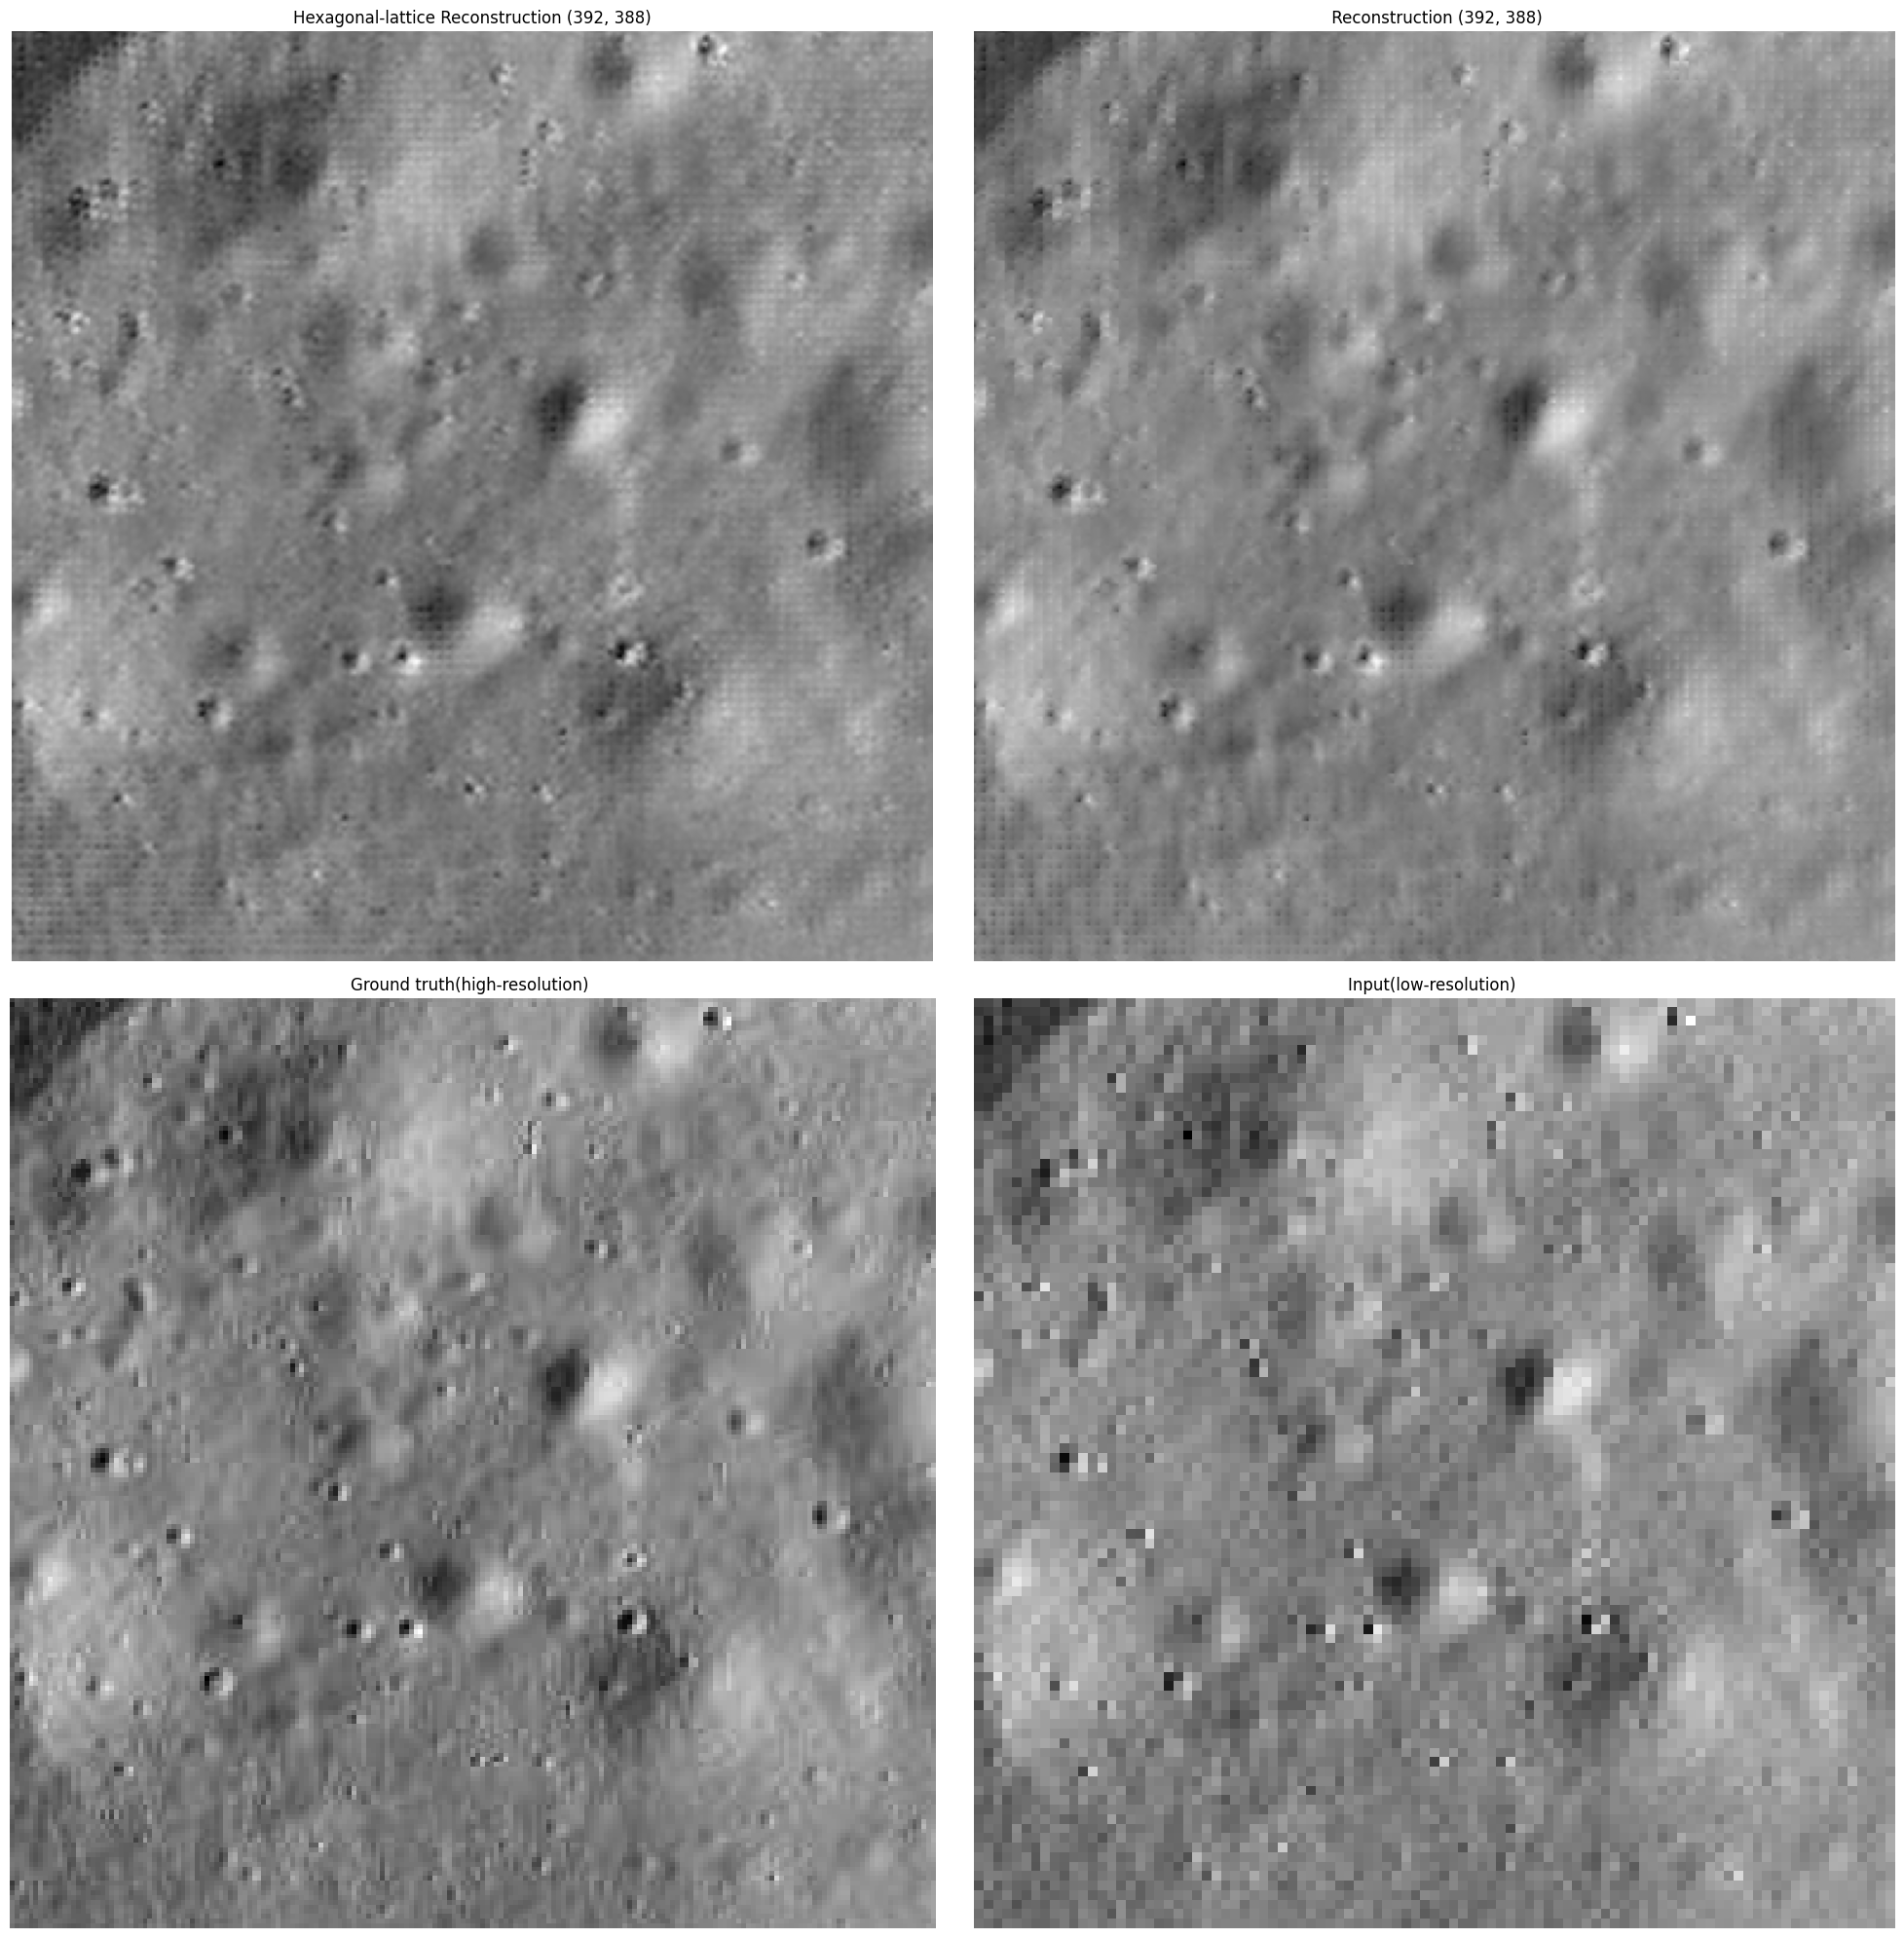

In [29]:
plt.figure(figsize=(20, 20))


plt.subplot(2, 2, 1)
plt.title(f"Hexagonal-lattice Reconstruction {raster_u8.shape}")
plt.imshow(raster_u8, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title(f" Reconstruction {raster_u8_sq.shape}")
plt.imshow(raster_u8_sq, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title(f"Ground truth(high-resolution) ")
plt.imshow(aligned_images_original[0], cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title(f"Input(low-resolution) ")
plt.imshow(aligned_images[0], cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.savefig("sq_hx_comparison.png", dpi=150)

plt.show()

## Edge detection and Global threshodling
なぜadaptive thresholdingでないかというと、気持ち悪い画像になったから


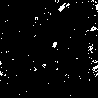

In [ ]:
from google.colab.patches import cv2_imshow

# 1. 読み込んだ画像を 0~255 の uint8 に変換する
img_uint8 = cv2.normalize(aligned_images[0], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 2. その後、閾値 150 で二値化する
T = 150
ret, img_b_thresh1 = cv2.threshold(img_uint8, T, 255, cv2.THRESH_BINARY)
cv2_imshow(img_b_thresh1)

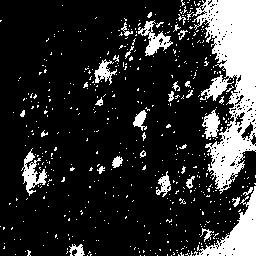

In [ ]:
img = cv2.imread('bs1.png')
# 1. 読み込んだ画像を 0~255 の uint8 に変換する
img_uint8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 2. その後、閾値 150 で二値化する
T = 150
ret, img_b_thresh2 = cv2.threshold(img_uint8, T, 255, cv2.THRESH_BINARY)
cv2_imshow(img_b_thresh2)

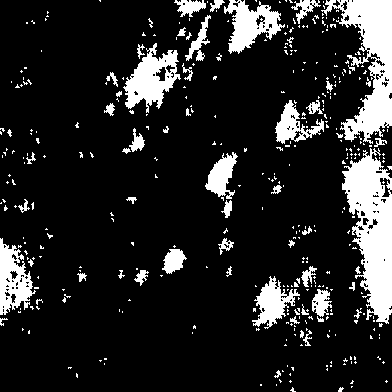

True

In [ ]:
#e = 0.03
#T0 = basicGlobalThreshold(img, e)
#print(T0)
T = 150
ret, img_b_thresh = cv2.threshold(raster_u8,T,255,cv2.THRESH_BINARY)
cv2_imshow(img_b_thresh)
cv2.imwrite("a.png",img_b_thresh)



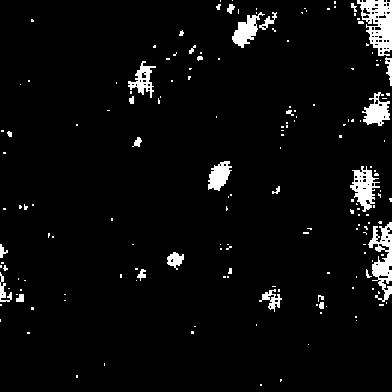

True

In [ ]:
#e = 0.03
#T0 = basicGlobalThreshold(img, e)
#print(T0)
T = 150
ret, img_b_thresh = cv2.threshold(raster_u8_sq,T,255,cv2.THRESH_BINARY)
cv2_imshow(img_b_thresh)
cv2.imwrite("a.png",img_b_thresh)



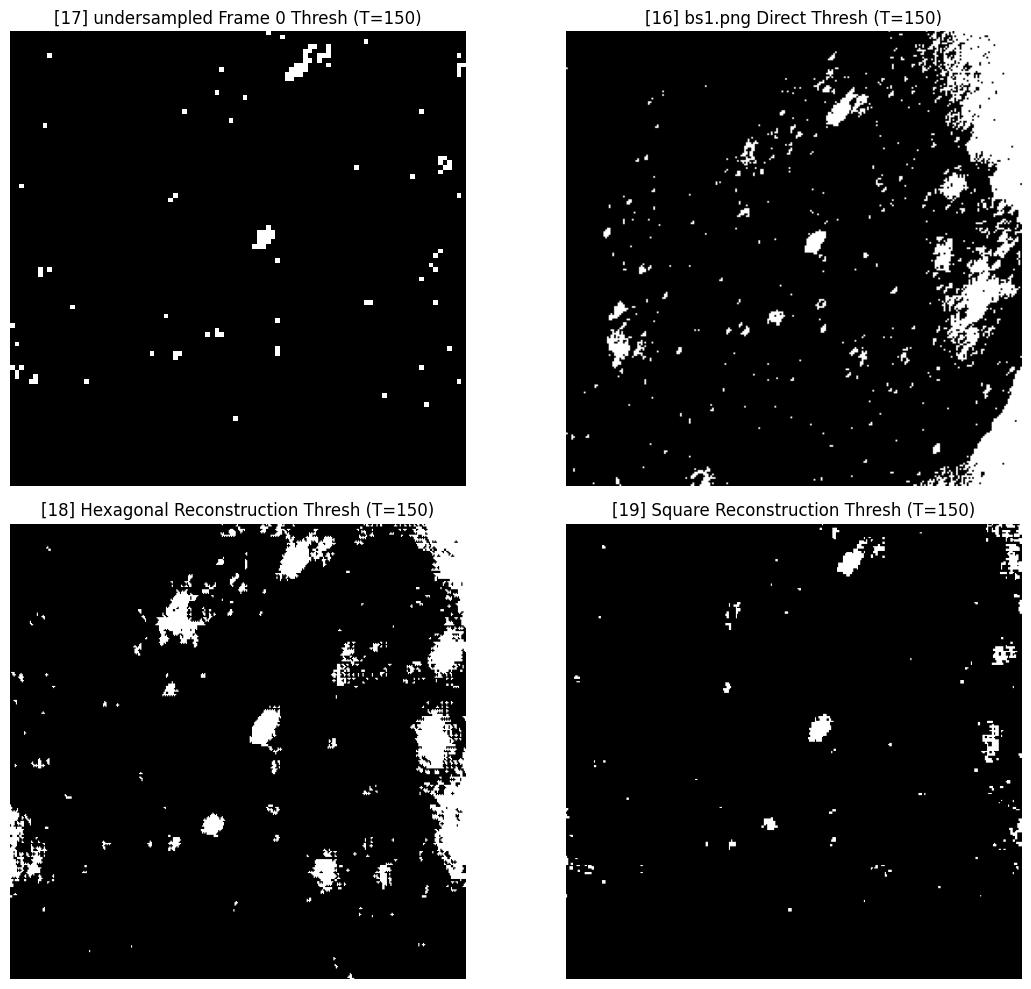

比較画像を 'threshold_comparison_2x2.png' として保存しました。


In [ ]:
# ======================================================
# [17]〜[19] の二値化結果を 2x2 で並べて比較表示
# ======================================================

# 1. 各セルの二値化処理を個別に再現（変数名が上書きされないように個別の変数に格納します）
T = 160

# [17] 原画像 (images[0]) の二値化
img_uint8_17 = cv2.normalize(aligned_images[0], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
_, thresh_17 = cv2.threshold(img_uint8_17, T, 255, cv2.THRESH_BINARY)

# [16] 直接読み込んだ 'bs1.png' の二値化
img_16 = cv2.imread('bs1.png')
img_uint8_16 = cv2.normalize(img_16, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
_, thresh_16 = cv2.threshold(img_uint8_16, T, 255, cv2.THRESH_BINARY)

# [18] 六角格子再構成 (raster_u8) の二値化
_, thresh_18 = cv2.threshold(raster_u8, T, 255, cv2.THRESH_BINARY)

# [19] 四角格子再構成 (raster_u8_sq) の二値化
_, thresh_19 = cv2.threshold(raster_u8_sq, T, 255, cv2.THRESH_BINARY)


# 2. matplotlib を使って 2x2 のグリッドに描画
plt.figure(figsize=(12, 10))

# 左上: [17]
plt.subplot(2, 2, 1)
plt.title("[17] undersampled Frame 0 Thresh (T=150)")
plt.imshow(thresh_17, cmap='gray')
plt.axis('off')

# 右上: [16]
plt.subplot(2, 2, 2)
plt.title("[16] bs1.png Direct Thresh (T=150)")
plt.imshow(thresh_16, cmap='gray')
plt.axis('off')

# 左下: [18]
plt.subplot(2, 2, 3)
plt.title("[18] Hexagonal Reconstruction Thresh (T=150)")
plt.imshow(thresh_18, cmap='gray')
plt.axis('off')

# 右下: [19]
plt.subplot(2, 2, 4)
plt.title("[19] Square Reconstruction Thresh (T=150)")
plt.imshow(thresh_19, cmap='gray')
plt.axis('off')

plt.tight_layout()

# 3. 比較画像を保存して表示
plt.savefig("threshold_comparison_2x2.png", dpi=150)
plt.show()

print("比較画像を 'threshold_comparison_2x2.png' として保存しました。")

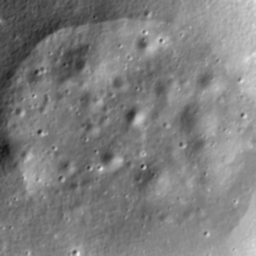

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
gaussian_blur_original = cv2.GaussianBlur(img_uint8, (3, 3), 1.0)

#cv2_imshow(gaussian_blur)



gaussian_blur = cv2.GaussianBlur(img_uint8, (5, 5), 1.0)

cv2_imshow(gaussian_blur_original)

##RL法の結果
わかったこととして、RL法は意味ない。

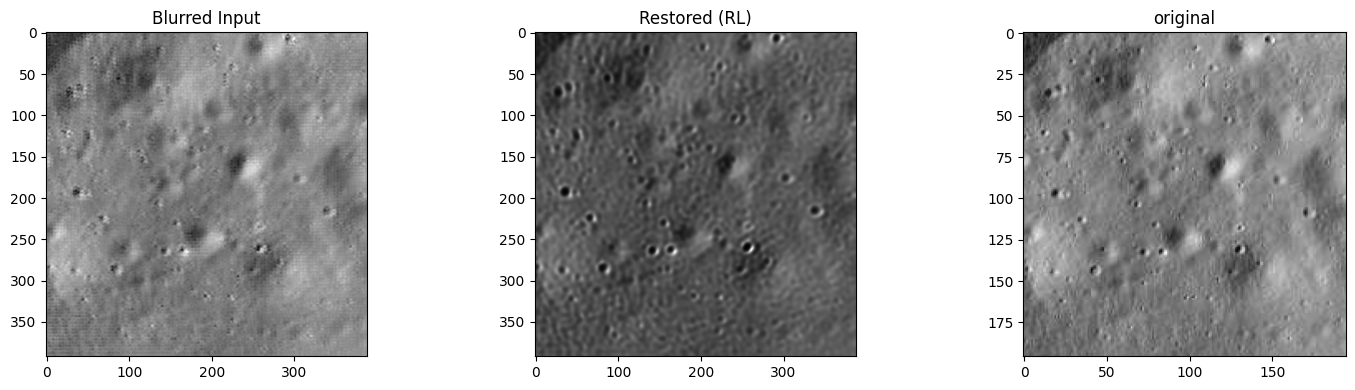

True

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

def richardson_lucy(image, psf, iterations=50):
    # 浮動小数点数に変換
    image = image.astype(np.float64)
    # PSFの正規化
    psf = psf / np.sum(psf)
    # 推定画像の初期化（元画像と同じサイズ）
    estimate = np.full(image.shape, 0.5, dtype=np.float64)
    psf_mirror = np.flip(psf)

    for _ in range(iterations):
        # 1. 現時点の推定画像をPSFで畳み込む
        conv = convolve2d(estimate, psf, mode='same', boundary='symm')
        # 2. 観測画像と畳み込み結果の比を計算
        relative_blur = image / (conv + 1e-12)
        # 3. 比をPSFの反転で畳み込み、補正係数を求める
        error_est = convolve2d(relative_blur, psf_mirror, mode='same', boundary='symm')
        # 4. 推定画像を更新
        estimate *= error_est

    return estimate

# --- 実行 ---
# 1. ぼやけている元画像を読み込む
# （もともとガウシアンがかかっている前提）
blur_img = cv2.imread('hex_reconstruction_k4.png', cv2.IMREAD_GRAYSCALE) / 255.0

# 2. 「かかっているはずの」ガウシアンPSFを定義する
# ここが重要です：実際に画像にかかっているぼけ具合に合わせて設定してください
px = 21  # PSFサイズ
sigma = 3.0 # ここを調整して、画像のぼけ具合と合わせる
x = np.linspace(-px//2, px//2, px)
x, y = np.meshgrid(x, x)
psf = np.exp(-(x**2 + y**2) / (2 * sigma**2))
psf /= np.sum(psf)

# 3. RL法で復元
restored_img = richardson_lucy(blur_img, psf, iterations=20)

# 表示
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1); plt.title("Blurred Input"); plt.imshow(blur_img, cmap='gray')
plt.subplot(1, 3, 2); plt.title("Restored (RL)"); plt.imshow(restored_img, cmap='gray')
plt.subplot(1, 3, 3); plt.title("original"); plt.imshow(aligned_images_original[0] , cmap='gray')
plt.tight_layout()
plt.savefig("rl_comparison.png", dpi=150)
plt.show()
# ファイル名と保存したい画像を指定（例: 'RL.png' という名前で保存）
cv2.imwrite('RL.png', (restored_img * 255).astype(np.uint8))

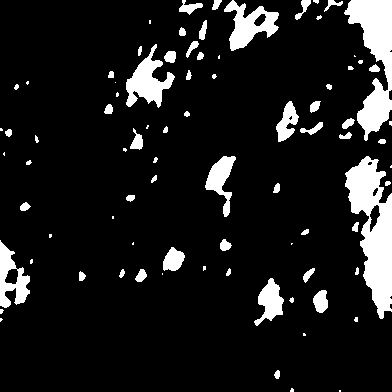

In [ ]:
img = cv2.imread('RL.png')
# 1. 読み込んだ画像を 0~255 の uint8 に変換する
img_uint8 = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 2. その後、閾値 150 で二値化する
T = 150
ret, img_b_thresh2 = cv2.threshold(img_uint8, T, 255, cv2.THRESH_BINARY)
cv2_imshow(img_b_thresh2)